# Step 1: Extract Raw Text from HSK Exam Files

**Kernel:** Python (ml-env) — `C:\ml-env\Scripts\python.exe`

Pipeline: Inventory → PDF (pdfplumber + PaddleOCR fallback) → Audio (Whisper) → Save

In [116]:
import re, warnings, os
from pathlib import Path
import pandas as pd
import pdfplumber
import fitz
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq

# Ensure ffmpeg is on PATH for this process — whisper shells out to it to decode
# audio. Relying on the inherited system PATH is unreliable: any process spawned
# before ffmpeg was installed (even indirectly, through a parent that was never
# relaunched) keeps a stale PATH snapshot, so injecting it explicitly here avoids
# that entirely regardless of restarts elsewhere.
FFMPEG_BIN = r"C:\Users\callm\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.1.2-full_build\bin"
if os.path.isdir(FFMPEG_BIN) and FFMPEG_BIN not in os.environ["PATH"]:
    os.environ["PATH"] = FFMPEG_BIN + os.pathsep + os.environ["PATH"]

# torch/whisper MUST be imported before paddleocr in this process — paddle and torch
# each bundle their own (different) libiomp5md.dll (Intel OpenMP runtime). Whichever
# loads second in-process conflicts and torch raises WinError 127 on shm.dll.
# Importing torch first here avoids that regardless of which cells get re-run later.
import torch
import whisper
from paddleocr import PaddleOCR
from IPython.display import display
warnings.filterwarnings("ignore")

DATA_DIR   = Path(r"C:\Users\callm\Downloads\hsk3-4 exam")
OUTPUT_DIR = Path(r"C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\raw")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_parquet(df, path):
    # pyarrow defaults string columns to large_string, which some viewers
    # (e.g. VS Code's built-in parquet preview) can't read ("Unrecognized
    # type: LargeUtf8"). Cast back to plain string before writing.
    table = pa.Table.from_pandas(df, preserve_index=False)
    fields = [f.with_type(pa.string()) if pa.types.is_large_string(f.type) else f
              for f in table.schema]
    table = table.cast(pa.schema(fields))
    pq.write_table(table, path)

import shutil
print("Packages OK")
print(f"Data dir: {DATA_DIR}")
print(f"ffmpeg found: {shutil.which('ffmpeg')}")

Packages OK
Data dir: C:\Users\callm\Downloads\hsk3-4 exam
ffmpeg found: C:\Users\callm\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.1.2-full_build\bin\ffmpeg.EXE


## 0 — HSK Wordlist Snapshot (call once, save locally)

In [132]:
import os, requests
from datetime import datetime, timezone
from dotenv import load_dotenv

load_dotenv(Path(r"C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\.env"))

WORDLIST_DIR  = Path(r"C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\processed")
WORDLIST_DIR.mkdir(parents=True, exist_ok=True)
SNAPSHOT_PATH = WORDLIST_DIR / "hsk_wordlist.parquet"
FORCE_REFRESH = True

if SNAPSHOT_PATH.exists() and not FORCE_REFRESH:
    df_wordlist = pd.read_parquet(SNAPSHOT_PATH)
    snap_time   = df_wordlist.attrs.get("snapshot_at", "unknown")
    print(f"Loaded snapshot ({len(df_wordlist)} words)  [FORCE_REFRESH=True to re-fetch]")

else:
    api_url = os.getenv("HSK_WORDLIST_API_URL", "").strip()
    api_key = os.getenv("HSK_WORDLIST_API_KEY", "").strip()
    if not api_url:
        raise ValueError("HSK_WORDLIST_API_URL not set in .env")
    headers = {"X-API-KEY": api_key} if api_key else {}

    # API ใช้ page/per_page (ไม่ใช่ skip/limit) — ดู openapi.json ของ /words
    # per_page สูงสุด 1000, metadata.has_next บอกว่ายังมีหน้าถัดไปหรือไม่
    PER_PAGE    = 1000
    all_records = []
    seen_ids    = set()
    page        = 1

    while True:
        resp = requests.get(api_url, headers=headers,
                            params={"page": page, "per_page": PER_PAGE}, timeout=30)
        resp.raise_for_status()
        raw      = resp.json()
        records  = raw.get("data", raw) if isinstance(raw, dict) else raw
        metadata = raw.get("metadata", {}) if isinstance(raw, dict) else {}

        new = [r for r in records if r.get("id") not in seen_ids]
        seen_ids.update(r["id"] for r in new)
        all_records.extend(new)
        print(f"  page={page:3d}  new={len(new):4d}  total={len(all_records)}"
              f"  (of {metadata.get('total_records', '?')})")

        if not metadata.get("has_next"):
            break
        page += 1

    print(f"\nTotal fetched: {len(all_records)} words")

    df_wordlist = pd.DataFrame(all_records)
    df_wordlist.columns = [c.strip().lower() for c in df_wordlist.columns]
    keep = [c for c in ["id","word","pinyin","definition","definition_th","level",
                         "example_sentence","example_pinyin"] if c in df_wordlist.columns]
    df_wordlist = df_wordlist[keep].copy()
    df_wordlist["level"] = pd.to_numeric(df_wordlist["level"], errors="coerce")

    snap_time = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
    df_wordlist.attrs["snapshot_at"] = snap_time
    save_parquet(df_wordlist, SNAPSHOT_PATH)

# ── Save CSV ──────────────────────────────────────────────────────────────────
full_csv   = WORDLIST_DIR / "hsk_wordlist.csv"
lookup_csv = WORDLIST_DIR / "hsk_word_level_lookup.csv"
df_wordlist.to_csv(full_csv, index=False, encoding="utf-8-sig")
df_wordlist[["word","level"]].to_csv(lookup_csv, index=False, encoding="utf-8-sig")

# ── Validate ──────────────────────────────────────────────────────────────────
print(f"Snapshot : {snap_time}")
print(f"Total    : {len(df_wordlist)} words")
print(f"\nWords per HSK level:")
print(df_wordlist.groupby("level").size().to_string())
missing = set(range(1, 10)) - set(df_wordlist["level"].dropna().astype(int))
print(f"\n⚠ Missing levels: {sorted(missing)}" if missing else "\n✓ All levels 1-9 present")
print(f"\nSaved:\n  {full_csv}\n  {lookup_csv}")
df_wordlist.head(5)

  page=  1  new=1000  total=1000  (of 7410)
  page=  2  new=1000  total=2000  (of 7410)
  page=  3  new=1000  total=3000  (of 7410)
  page=  4  new=1000  total=4000  (of 7410)
  page=  5  new=1000  total=5000  (of 7410)
  page=  6  new=1000  total=6000  (of 7410)
  page=  7  new=1000  total=7000  (of 7410)
  page=  8  new= 410  total=7410  (of 7410)

Total fetched: 7410 words
Snapshot : 2026-07-03T06:19:28Z
Total    : 7410 words

Words per HSK level:
level
1.0     497
2.0     758
3.0     962
4.0    1003
5.0    1317
6.0    2872

⚠ Missing levels: [7, 8, 9]

Saved:
  C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\processed\hsk_wordlist.csv
  C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\processed\hsk_word_level_lookup.csv


,id,word,pinyin,definition,definition_th,level,example_sentence,example_pinyin
0,1,包,"Bāo, bāo",bag; package; to wrap; to include,กระเป๋า; ห่อ; รวม,1.0,我有一个包。,Wǒ yǒu yī gè bāo.
1,2,杯,bēi,cup; glass; trophy; classifier for containers ...,ถ้วย; แก้ว; ถ้วยรางวัล; หน่วยนับสำหรับภาชนะบรร...,1.0,我有一个杯子。,Wǒ yǒu yī gè bēizi.
2,3,本子,běn zi,"notebook, book","สมุดบันทึก, สมุด",1.0,我有一个本子。,Wǒ yǒu yī gè běn zi.
3,4,别人,bié ren,"other people, others","คนอื่น, ผู้อื่น",1.0,别人在看书。,bié ren zài kàn shū.
4,5,比,"Bǐ, bǐ, bì",to compare,เปรียบเทียบ,1.0,我比你高。,Wǒ bǐ nǐ gāo.


## 1 — Parse filename

In [118]:
EXAM_ID_RE = re.compile(r"^(H([34])\d{4}[A-Z]?)", re.IGNORECASE)

def parse_filename(filename):
    m = EXAM_ID_RE.match(filename)
    if not m: return None, None
    return m.group(1).upper(), int(m.group(2))

tests = ["H31001.pdf","H31114 Audio.mp3","H31327-exam-paper.pdf","H31553B_copy.pdf","H40000_copy.pdf"]
for f in tests:
    print(f"{f:40s} -> {parse_filename(f)}")

H31001.pdf                               -> ('H31001', 3)
H31114 Audio.mp3                         -> ('H31114', 3)
H31327-exam-paper.pdf                    -> ('H31327', 3)
H31553B_copy.pdf                         -> ('H31553B', 3)
H40000_copy.pdf                          -> ('H40000', 4)


## 2 — Inventory + dedup

In [119]:
def file_priority(filename):
    name = filename.lower()
    score = 0
    if "_copy"  in name: score += 10
    if "-audio" in name: score += 10
    if "试卷"   in name: score += 5
    if "(1)"    in name: score += 3
    return score

rows = []
for f in sorted(DATA_DIR.iterdir()):
    ext = f.suffix.lower()
    if ext not in (".pdf",".mp3",".wav",".m4a",".flac"): continue
    exam_id, hsk_level = parse_filename(f.name)
    if not exam_id:
        print(f"[SKIP] {f.name}"); continue
    rows.append({"exam_id":exam_id, "hsk_level":hsk_level,
        "source_type":"reading" if ext==".pdf" else "listening",
        "filename":f.name, "filepath":str(f),
        "size_mb":round(f.stat().st_size/1_048_576, 2),
        "_priority":file_priority(f.name)})

raw_inv = pd.DataFrame(rows)
inventory = (
    raw_inv.sort_values("_priority")
    .drop_duplicates(subset=["exam_id","source_type"], keep="first")
    .drop(columns=["_priority"])
    .sort_values(["hsk_level","exam_id","source_type"])
    .reset_index(drop=True)
)

dups = raw_inv[raw_inv.duplicated(subset=["exam_id","source_type"], keep=False)]
if len(dups):
    print("Duplicates removed:")
    for (eid, st), g in dups.groupby(["exam_id","source_type"]):
        g = g.sort_values("_priority")
        keep_fn = g.iloc[0]['filename']
        drop_fns = g.iloc[1:]['filename'].tolist()
        print(f"  {eid} [{st}] keep={keep_fn}  drop={drop_fns}")
    print()

print(f"raw={len(raw_inv)}  after dedup={len(inventory)}")
print(inventory.groupby(["hsk_level","source_type"]).size().to_string())
pdf_ids = set(inventory[inventory.source_type=="reading"].exam_id)
aud_ids = set(inventory[inventory.source_type=="listening"].exam_id)
print(f"PDF only (no audio): {sorted(pdf_ids - aud_ids)}")
print(f"Audio only (no PDF): {sorted(aud_ids - pdf_ids)}")
inventory

Duplicates removed:
  H31333 [reading] keep=H31333.pdf  drop=['H31333(1).pdf']
  H41113 [listening] keep=H41113 Audio.mp3  drop=['H41113-Audio.mp3']
  H41113 [reading] keep=H41113.pdf  drop=['H41113_copy.pdf']
  H41114 [reading] keep=H41114.pdf  drop=['H41114_copy.pdf']
  H41116 [listening] keep=H41116 Audio.mp3  drop=['H41116-Audio.mp3']

raw=135  after dedup=130
hsk_level  source_type
3          listening      33
           reading        33
4          listening      32
           reading        32
PDF only (no audio): []
Audio only (no PDF): []


,exam_id,hsk_level,source_type,filename,filepath,size_mb
0,H30000,3,listening,H30000 Audio.mp3,C:\Users\callm\Downloads\hsk3-4 exam\H30000 Au...,16.99
1,H30000,3,reading,H30000_copy.pdf,C:\Users\callm\Downloads\hsk3-4 exam\H30000_co...,1.99
2,H31001,3,listening,H31001.mp3,C:\Users\callm\Downloads\hsk3-4 exam\H31001.mp3,4.16
3,H31001,3,reading,H31001.pdf,C:\Users\callm\Downloads\hsk3-4 exam\H31001.pdf,0.58
4,H31002,3,listening,H31002.mp3,C:\Users\callm\Downloads\hsk3-4 exam\H31002.mp3,4.16
...,...,...,...,...,...,...
125,H41553B,4,reading,H41553B_copy.pdf,C:\Users\callm\Downloads\hsk3-4 exam\H41553B_c...,0.72
126,H41553C,4,listening,H41553C Audio.mp3,C:\Users\callm\Downloads\hsk3-4 exam\H41553C A...,4.78
127,H41553C,4,reading,H41553C_copy.pdf,C:\Users\callm\Downloads\hsk3-4 exam\H41553C_c...,0.71
128,H41553D,4,listening,H41553D Audio.mp3,C:\Users\callm\Downloads\hsk3-4 exam\H41553D A...,4.66


## 3 — PDF → text (pdfplumber + PaddleOCR fallback)

In [120]:
# โหลด PaddleOCR ครั้งเดียว (paddleocr 2.x)
ocr_engine = PaddleOCR(use_angle_cls=True, lang="ch", show_log=False)
print("PaddleOCR ready.")

PaddleOCR ready.


In [121]:
def ocr_pdf(filepath):
    """Render PDF pages to images then run PaddleOCR."""
    try:
        doc = fitz.open(filepath)
        page_texts = []
        for page in doc:
            mat = fitz.Matrix(200/72, 200/72)
            pix = page.get_pixmap(matrix=mat, colorspace=fitz.csRGB)
            img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, 3)
            result = ocr_engine.ocr(img, cls=True)
            if result and result[0]:
                page_texts.append("\n".join(line[1][0] for line in result[0]))
        doc.close()
        text = "\n".join(page_texts)
        return text, ("ocr_ok" if text.strip() else "ocr_empty")
    except Exception as e:
        return "", f"ocr_error:{e}"


def extract_pdf_text(filepath):
    """
    Conditions for OCR fallback:
      1. no text layer at all         → scanned
      2. chars/page < 150             → scanned (pdfplumber grabbed only headers/metadata)
      3. >10 (cid:N) artifacts        → broken font encoding
    notes: ok | ocr_ok | sparse_then_ocr_ok | cid_then_ocr_ok | ocr_empty | error:...
    """
    try:
        parts = []
        with pdfplumber.open(filepath) as pdf:
            n_pages = max(len(pdf.pages), 1)
            for page in pdf.pages:
                t = page.extract_text()
                if t and t.strip():
                    parts.append(t)
        text = "\n".join(parts)
    except Exception as e:
        return "", f"error:{e}"

    # condition 1: no text at all
    if not text.strip():
        return ocr_pdf(filepath)

    # condition 2: suspiciously sparse — probably scanned with only metadata extracted
    chars_per_page = len(text) / n_pages
    if chars_per_page < 150:
        ocr_text, ocr_note = ocr_pdf(filepath)
        return ocr_text, f"sparse_then_{ocr_note}"

    # condition 3: broken font encoding
    if len(re.findall(r"\(cid:\d+\)", text)) > 10:
        ocr_text, ocr_note = ocr_pdf(filepath)
        return ocr_text, f"cid_then_{ocr_note}"

    return text, "ok"


pdf_rows = inventory[inventory.source_type == "reading"].copy()
PDF_CKPT = OUTPUT_DIR / "_pdf_progress.parquet"

# resume from checkpoint: reuse rows that already finished successfully, retry the rest
results = []
done_filenames = set()
if PDF_CKPT.exists():
    prev = pd.read_parquet(PDF_CKPT)
    prev_ok = prev[prev["notes"].str.contains("ok", na=False) & ~prev["notes"].str.contains("empty", na=False)]
    results = prev_ok.to_dict("records")
    done_filenames = set(prev_ok["filename"])
    print(f"Resuming: {len(done_filenames)} PDFs already done, skipping them.")

for _, row in pdf_rows.iterrows():
    if row["filename"] in done_filenames:
        continue
    text, note = extract_pdf_text(row["filepath"])
    results.append({**row.to_dict(), "text": text, "text_length": len(text), "notes": note})
    icon = "ok" if "ok" in note else "!!"
    print(f"[{icon}] {row['filename']:45s}  chars={len(text):6d}  {note}")
    # save progress after every file so OCR fallback (slow) survives an interruption
    save_parquet(pd.DataFrame(results).drop(columns=["filepath"], errors="ignore"), PDF_CKPT)

df_pdf = pd.DataFrame(results).drop(columns=["filepath"], errors="ignore")
save_parquet(df_pdf, OUTPUT_DIR / "raw_extractions_pdf.parquet")
print(f"\nDone. {len(df_pdf)} PDFs -> saved to {OUTPUT_DIR / 'raw_extractions_pdf.parquet'}")
print(df_pdf.notes.value_counts().to_string())

Resuming: 65 PDFs already done, skipping them.

Done. 65 PDFs -> saved to C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\raw\raw_extractions_pdf.parquet
notes
ok                    50
ocr_ok                 9
sparse_then_ocr_ok     5
cid_then_ocr_ok        1


In [122]:
# ── Diagnostic: วิเคราะห์ไฟล์ที่ chars น้อยผิดปกติ ──────────────────────────
import pdfplumber

def get_page_info(filepath):
    """Return (page_count, has_text_layer, sample_text)"""
    try:
        with pdfplumber.open(filepath) as pdf:
            n = len(pdf.pages)
            texts = [p.extract_text() or "" for p in pdf.pages]
            full = "\n".join(texts)
            return n, bool(full.strip()), full[:200].replace("\n", " ")
    except Exception as e:
        return 0, False, str(e)

# จัดกลุ่มตาม char range
bins   = [0, 600, 4000, 7000, 20000]
labels = ["<600 (ผิดปกติ)", "600-4k (ครึ่งเดียว)", "4k-7k (ปกติ HSK3)", ">7k (ปกติ HSK4)"]
df_pdf["char_group"] = pd.cut(df_pdf["text_length"], bins=bins, labels=labels)

print("=== สรุปตามกลุ่ม char ===")
print(df_pdf.groupby("char_group", observed=True)[["exam_id","text_length","size_mb"]].agg(
    count=("exam_id","count"),
    avg_chars=("text_length","mean"),
    avg_mb=("size_mb","mean"),
).round(1).to_string())

print("\n=== ไฟล์ <600 chars — ตรวจสอบ page count ===")
tiny = df_pdf[df_pdf["text_length"] < 600].copy()
inv_path = inventory[inventory.source_type=="reading"][["exam_id","filepath","size_mb"]].set_index("exam_id")

for _, row in tiny.iterrows():
    fp = inv_path.loc[row["exam_id"], "filepath"] if row["exam_id"] in inv_path.index else None
    pages, has_text, sample = get_page_info(fp) if fp else (0, False, "filepath not found")
    print(f"\n  {row['filename']:35s}  size={row['size_mb']:5.2f}MB  chars={row['text_length']:4d}  pages={pages}  has_text={has_text}")
    print(f"  text preview: {repr(sample[:120])}")

print("\n=== ไฟล์ 600-4k chars — ตรวจสอบ page count ===")
half = df_pdf[(df_pdf["text_length"] >= 600) & (df_pdf["text_length"] < 4000)].copy()
for _, row in half.iterrows():
    fp = inv_path.loc[row["exam_id"], "filepath"] if row["exam_id"] in inv_path.index else None
    pages, has_text, sample = get_page_info(fp) if fp else (0, False, "filepath not found")
    print(f"  {row['filename']:35s}  size={row['size_mb']:5.2f}MB  chars={row['text_length']:4d}  pages={pages}")

=== สรุปตามกลุ่ม char ===
                     count  avg_chars  avg_mb
char_group                                   
600-4k (ครึ่งเดียว)      8     3816.6     3.7
4k-7k (ปกติ HSK3)       23     6149.0     1.6
>7k (ปกติ HSK4)         34     8652.8     0.8

=== ไฟล์ <600 chars — ตรวจสอบ page count ===

=== ไฟล์ 600-4k chars — ตรวจสอบ page count ===
  H31327-exam-paper.pdf                size= 0.47MB  chars=3658  pages=14
  H31329-exam-paper.pdf                size= 0.43MB  chars=3673  pages=14
  H31330-exam-paper.pdf                size= 0.42MB  chars=3676  pages=14
  H31332-exam-paper.pdf                size= 0.43MB  chars=3672  pages=14
  H31335_copy.pdf                      size= 6.61MB  chars=3971  pages=16
  H31446_copy.pdf                      size= 7.27MB  chars=3990  pages=16
  H31447_copy.pdf                      size= 7.22MB  chars=3932  pages=16
  H31448_copy.pdf                      size= 7.14MB  chars=3961  pages=16


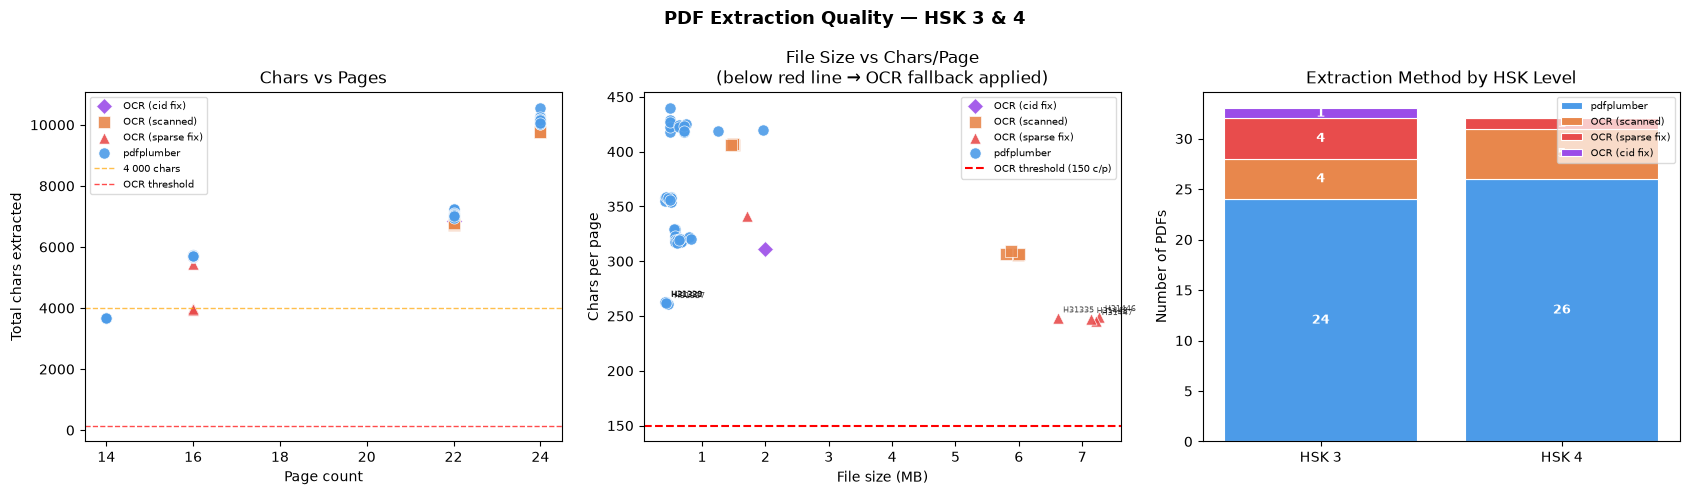

Saved → C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\raw\pdf_extraction_analysis.png

=== สรุปตาม method ===


,files,avg_chars,avg_pages,avg_chars_per_page,avg_mb
method,,,,,
OCR (cid fix),1,6854.0,22.0,311.5,2.0
OCR (scanned),9,8422.6,23.1,362.3,3.5
OCR (sparse fix),5,4261.8,16.0,266.4,6.0
pdfplumber,50,7243.7,20.3,352.2,0.6


In [123]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── เตรียมข้อมูล ──────────────────────────────────────────────────────────────
plot_df = df_pdf.copy()

def count_pages(exam_id):
    row = inventory[(inventory.exam_id == exam_id) & (inventory.source_type == "reading")]
    if row.empty: return 0
    try:
        with pdfplumber.open(row.iloc[0]["filepath"]) as pdf:
            return len(pdf.pages)
    except:
        return 0

plot_df["pages"] = plot_df["exam_id"].apply(count_pages)
plot_df["chars_per_page"] = (plot_df["text_length"] / plot_df["pages"].clip(lower=1)).round(1)

def method_label(note):
    if note == "ok":          return "pdfplumber"
    if note == "ocr_ok":      return "OCR (scanned)"
    if "sparse" in note:      return "OCR (sparse fix)"
    if "cid"    in note:      return "OCR (cid fix)"
    return "other"

plot_df["method"] = plot_df["notes"].apply(method_label)

palette = {
    "pdfplumber":      "#4C9BE8",
    "OCR (scanned)":   "#E8874C",
    "OCR (sparse fix)":"#E84C4C",
    "OCR (cid fix)":   "#9B4CE8",
}
mkr = {
    "pdfplumber":      "o",
    "OCR (scanned)":   "s",
    "OCR (sparse fix)":"^",
    "OCR (cid fix)":   "D",
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("PDF Extraction Quality — HSK 3 & 4", fontsize=13, fontweight="bold")

# ── Plot 1: chars vs pages ────────────────────────────────────────────────────
ax = axes[0]
for method, g in plot_df.groupby("method"):
    ax.scatter(g["pages"], g["text_length"],
               c=palette[method], marker=mkr[method], label=method,
               s=65, alpha=0.9, edgecolors="white", linewidths=0.5)
ax.axhline(4000, color="orange", linestyle="--", linewidth=1, alpha=0.7, label="4 000 chars")
ax.axhline(150,  color="red",    linestyle="--", linewidth=1, alpha=0.7, label="OCR threshold")
ax.set_xlabel("Page count", fontsize=10)
ax.set_ylabel("Total chars extracted", fontsize=10)
ax.set_title("Chars vs Pages")
ax.legend(fontsize=7.5, framealpha=0.7)

# ── Plot 2: MB vs chars/page ─ แสดง OCR threshold line ──────────────────────
ax = axes[1]
for method, g in plot_df.groupby("method"):
    ax.scatter(g["size_mb"], g["chars_per_page"],
               c=palette[method], marker=mkr[method], label=method,
               s=65, alpha=0.9, edgecolors="white", linewidths=0.5)
ax.axhline(150, color="red", linestyle="--", linewidth=1.5,
           label="OCR threshold (150 c/p)")
# annotate ไฟล์ที่น่าสนใจ
for _, row in plot_df[plot_df["chars_per_page"] < 300].iterrows():
    ax.annotate(row["exam_id"], (row["size_mb"], row["chars_per_page"]),
                fontsize=6, alpha=0.7, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("File size (MB)", fontsize=10)
ax.set_ylabel("Chars per page", fontsize=10)
ax.set_title("File Size vs Chars/Page\n(below red line → OCR fallback applied)")
ax.legend(fontsize=7.5, framealpha=0.7)

# ── Plot 3: stacked bar — method × hsk_level ─────────────────────────────────
ax = axes[2]
order   = ["pdfplumber", "OCR (scanned)", "OCR (sparse fix)", "OCR (cid fix)"]
hsk_lvl = sorted(plot_df["hsk_level"].unique())
x       = range(len(hsk_lvl))
bottom  = [0] * len(hsk_lvl)

for method in order:
    vals = [
        len(plot_df[(plot_df["hsk_level"] == lv) & (plot_df["method"] == method)])
        for lv in hsk_lvl
    ]
    bars = ax.bar(x, vals, bottom=bottom, color=palette[method],
                  label=method, edgecolor="white", linewidth=0.8)
    for rect, val, bot in zip(bars, vals, bottom):
        if val > 0:
            ax.text(rect.get_x() + rect.get_width()/2,
                    bot + val/2, str(val),
                    ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_xticks(list(x))
ax.set_xticklabels([f"HSK {lv}" for lv in hsk_lvl], fontsize=10)
ax.set_ylabel("Number of PDFs", fontsize=10)
ax.set_title("Extraction Method by HSK Level")
ax.legend(fontsize=7.5, framealpha=0.7, loc="upper right")

plt.tight_layout()
out_path = OUTPUT_DIR / "pdf_extraction_analysis.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")

# ── ตารางสรุป ─────────────────────────────────────────────────────────────────
print("\n=== สรุปตาม method ===")
display(plot_df.groupby("method").agg(
    files             =("exam_id",        "count"),
    avg_chars         =("text_length",    "mean"),
    avg_pages         =("pages",          "mean"),
    avg_chars_per_page=("chars_per_page", "mean"),
    avg_mb            =("size_mb",        "mean"),
).round(1))

In [124]:
# ── Completeness Validation ────────────────────────────────────────────────────
import re

SECTION_RE  = re.compile(r'第[一二三四五六七八九十]+部分')
QUESTION_RE = re.compile(r'(?<!\d)(\d{1,2})(?=\s*[．。、）\)\.]\s*[一-鿿])')
EXPECTED_SECTIONS = 3
EXPECTED_Q = {3: 40, 4: 45}

def file_type(filename):
    f = filename.lower()
    if "exam-paper" in f: return "instruction_sheet"
    if "试卷"       in f: return "instruction_sheet"
    return "full_exam"

df_pdf["file_type"] = df_pdf["filename"].apply(file_type)
instruction_files = df_pdf[df_pdf["file_type"] == "instruction_sheet"]
full_exam_files   = df_pdf[df_pdf["file_type"] == "full_exam"]

print(f"full_exam:         {len(full_exam_files)} files")
print(f"instruction_sheet: {len(instruction_files)} files\n")

# ── A) Validate full exam ─────────────────────────────────────────────────────
def validate_full(row):
    text = row["text"]
    lv   = row["hsk_level"]
    n_sections = len(set(SECTION_RE.findall(text)))
    nums = [int(m) for m in QUESTION_RE.findall(text) if 1 <= int(m) <= 60]
    max_q = max(nums) if nums else 0
    expected_q = EXPECTED_Q.get(lv, 0)
    q_coverage = round(max_q / expected_q * 100, 1) if expected_q else 0
    issues = []
    if n_sections < EXPECTED_SECTIONS:
        issues.append(f"sections={n_sections}/{EXPECTED_SECTIONS}")
    if max_q < expected_q * 0.8:
        issues.append(f"max_q={max_q}/{expected_q}")
    return pd.Series({"n_sections": n_sections, "max_q": max_q,
                      "q_coverage%": q_coverage,
                      "issues": "; ".join(issues) if issues else "OK"})

val_full = full_exam_files.apply(validate_full, axis=1)
vdf_full = pd.concat([
    full_exam_files[["exam_id","hsk_level","filename","text_length","notes"]].reset_index(drop=True),
    val_full.reset_index(drop=True)
], axis=1)

ok_f = (vdf_full["issues"] == "OK").sum()
print(f"[Full Exam]  ✓ {ok_f}/{len(vdf_full)} passed")
if ok_f < len(vdf_full):
    display(vdf_full[vdf_full["issues"] != "OK"])

# ── B) Validate instruction sheet ─────────────────────────────────────────────
# criteria: 注意 header + 听力/阅读/书写 ทั้ง 3 คำ + notice items 一、二、三
NOTICE_RE  = re.compile(r'注\s*意')
SKILLS_RE  = {
    "听力": re.compile(r'听\s*力'),
    "阅读": re.compile(r'阅\s*读'),
    "书写": re.compile(r'书\s*写'),
}
ITEMS_RE   = re.compile(r'[一二三][、，。]')   # notice items

def validate_instruction(row):
    text = row["text"]
    has_notice = bool(NOTICE_RE.search(text))
    skills     = {k: bool(v.search(text)) for k, v in SKILLS_RE.items()}
    n_items    = len(set(ITEMS_RE.findall(text)))
    issues = []
    if not has_notice:
        issues.append("no 注意 header")
    missing = [k for k, found in skills.items() if not found]
    if missing:
        issues.append(f"missing: {','.join(missing)}")
    if n_items < 3:
        issues.append(f"notice_items={n_items}/3")
    return pd.Series({
        "has_注意": has_notice,
        "has_听力": skills["听力"],
        "has_阅读": skills["阅读"],
        "has_书写": skills["书写"],
        "notice_items": n_items,
        "issues": "; ".join(issues) if issues else "OK",
    })

val_inst = instruction_files.apply(validate_instruction, axis=1)
vdf_inst = pd.concat([
    instruction_files[["exam_id","hsk_level","filename","text_length","notes"]].reset_index(drop=True),
    val_inst.reset_index(drop=True)
], axis=1)

ok_i = (vdf_inst["issues"] == "OK").sum()
print(f"[Instruction] ✓ {ok_i}/{len(vdf_inst)} passed")
if ok_i < len(vdf_inst):
    print("\n=== Instruction sheet ที่มีปัญหา ===")
    display(vdf_inst[vdf_inst["issues"] != "OK"])
else:
    print("✓ ทุก instruction sheet มีครบ: 注意 + 听力/阅读/书写 + 三รายการ\n")

# ── summary table ──────────────────────────────────────────────────────────────
print("\n=== Instruction sheet detail ===")
display(vdf_inst[["exam_id","hsk_level","filename","text_length","notes",
                   "has_注意","has_听力","has_阅读","has_书写","notice_items","issues"]])

full_exam:         48 files
instruction_sheet: 17 files

[Full Exam]  ✓ 48/48 passed
[Instruction] ✓ 17/17 passed
✓ ทุก instruction sheet มีครบ: 注意 + 听力/阅读/书写 + 三รายการ


=== Instruction sheet detail ===


,exam_id,hsk_level,filename,text_length,notes,has_注意,has_听力,has_阅读,has_书写,notice_items,issues
0,H31327,3,H31327-exam-paper.pdf,3658,ok,True,True,True,True,3,OK
1,H31329,3,H31329-exam-paper.pdf,3673,ok,True,True,True,True,4,OK
2,H31330,3,H31330-exam-paper.pdf,3676,ok,True,True,True,True,3,OK
3,H31332,3,H31332-exam-paper.pdf,3672,ok,True,True,True,True,3,OK
4,H41006,4,H41006试卷.pdf,5718,ok,True,True,True,True,3,OK
5,H41007,4,H41007试卷.pdf,5720,ok,True,True,True,True,3,OK
6,H41008,4,H41008试卷.pdf,5681,ok,True,True,True,True,3,OK
7,H41009,4,H41009试卷.pdf,5734,ok,True,True,True,True,3,OK
8,H41218,4,H41218试卷.pdf,5658,ok,True,True,True,True,4,OK
9,H41219,4,H41219试卷.pdf,5661,ok,True,True,True,True,3,OK


In [125]:
# ── Debug: ดู text จริงของไฟล์ที่ถูก flag ────────────────────────────────────
# ดู 1 ตัวอย่างจากแต่ละกลุ่ม

samples = {
    "H31327 (exam-paper HSK3)": "H31327",
    "H41006 (试卷 HSK4)":       "H41006",
    "H41327 (exam-paper HSK4)": "H41327",
}

for label, eid in samples.items():
    row = df_pdf[df_pdf["exam_id"] == eid]
    if row.empty:
        print(f"[{label}] — ไม่พบใน df_pdf"); continue
    text = row.iloc[0]["text"]
    print(f"\n{'='*65}")
    print(f"  {label}  (total {len(text)} chars)")
    print(f"{'='*65}")
    print("--- 400 ตัวแรก ---")
    print(text[:400])
    print("\n--- 400 ตัวกลาง ---")
    mid = len(text) // 2
    print(text[mid:mid+400])


  H31327 (exam-paper HSK3)  (total 3658 chars)
--- 400 ตัวแรก ---
新 汉 语 水 平 考 试
HSK（三级）
H31327
注 意
一、HSK（三级）分三部分：
1．听力（40 题，约35分钟）
2．阅读（30 题，30分钟）
3．书写（10 题，15分钟）
二、听力结束后，有 5分钟填写答题卡。
三、全部考试约 90分钟（含考生填写个人信息时间 5分钟）。
中国 北京 国家汉办/孔子学院总部 编制
一、听 力
第 一 部 分
第 1-5 题
A B
C D
E F
例如：男：喂，请问张经理在吗？
女：他正在开会，您半个小时以后再打，好吗？ D
1．
2．
3．
4．
5．
H31327 - 1
第 6-10 题
A B
C D
E
6．
7．
8．
9．
10．
H31327 - 2
第 二 部 分
第 11-20 题
例如：为了让自己更健康，他每天都花一个小时去锻炼身体。
√
★ 他希望自己很健康。 （ ）
今天我想早点儿回家。看了看手表，才 5 点

--- 400 ตัวกลาง ---
不吃米饭，吃面条儿。 （ ）
50．你出门记得带把伞。 （ ）
H31327 - 7
第 二 部 分
第 51-55 题
A 糖 B 安静 C 出现 D 结束 E 声音 F 节日
例如：她说话的（ E ）多好听啊！
51．牛奶太甜了，（ ）放多了吧？
52．太阳和月亮会在同一个时候（ ）吗？
53．表演几点（ ）？我去接你。
54．祝您（ ）快乐，这是我们送您的礼物，希望您喜欢。
55．山上很（ ），早上起床的时候还能听见鸟的叫声。
H31327 - 8
第 56-60 题
A 参加 B 米 C 坏 D 爱好 E 洗手间 F 当然
例如：A：你有什么（ D ）？
B：我喜欢体育。
56．A：你怎么这么晚才到？
B：对不起，我的自行车半路突然（ ）了。
57．A：下周我要去旅游，能借你的照相机用一下吗？
B：（ ）可以，你打算去哪儿？
58．A：你上午没出去？
B：没出去，我把厨房和（ ）都

  H41006 (试卷 HSK4)  (total 5718 chars)
--- 400 ตัวแรก ---
新 汉 语 水 平 考 试
HSK（四级）
H41006
注 意
一、HSK（四级）分三部分：
1．听

## 4 — Audio → text (Whisper)

> ตั้ง `TEST_ONLY = True` เพื่อทดสอบ 1 ไฟล์ก่อน เปลี่ยนเป็น `False` เมื่อ batch ทั้งหมด

In [126]:
import whisper

WHISPER_MODEL = "small"  # tiny | base | small | medium | large -- small: no GPU on this machine (AMD, no CUDA), medium is far too slow on CPU
TEST_ONLY     = False     # False = transcribe all listening files

print(f"Loading Whisper [{WHISPER_MODEL}] ...")
model = whisper.load_model(WHISPER_MODEL)
print("Whisper ready.")

Loading Whisper [small] ...
Whisper ready.


In [127]:
audio_rows = inventory[inventory.source_type == "listening"].copy()
if TEST_ONLY:
    audio_rows = audio_rows.head(1)
    test_fn = audio_rows.iloc[0]['filename']
    print(f"TEST_ONLY -- transcribing: {test_fn}")

AUDIO_CKPT = OUTPUT_DIR / "_audio_progress.parquet"

# resume: skip files a previous (interrupted) run already transcribed
if AUDIO_CKPT.exists():
    done_df = pd.read_parquet(AUDIO_CKPT)
    done_filenames = set(done_df["filename"])
    audio_results = done_df.to_dict("records")
    print(f"Resuming -- {len(done_filenames)} files already done, skipping them")
else:
    done_filenames = set()
    audio_results = []

remaining = audio_rows[~audio_rows["filename"].isin(done_filenames)]

for i, (_, row) in enumerate(remaining.iterrows(), 1):
    print(f"[{i}/{len(remaining)}] {row['filename']} ({row['size_mb']} MB) ...")
    try:
        # temperature=0.0 (a single float, not the default tuple) disables
        # whisper's temperature-fallback retry loop -- that retry loop is what
        # was causing wildly inconsistent per-file times on CPU
        result = model.transcribe(row["filepath"], language="zh", temperature=0.0)
        text, note = result["text"], "ok"
    except Exception as e:
        text, note = "", f"error:{e}"
    audio_results.append({**row.to_dict(), "text": text, "text_length": len(text), "notes": note})
    print(f"   {len(text)} chars | {repr(text[:80].strip())}")
    # save progress after every file so a long batch survives an interruption
    save_parquet(pd.DataFrame(audio_results).drop(columns=["filepath"], errors="ignore"), AUDIO_CKPT)

df_audio = pd.DataFrame(audio_results).drop(columns=["filepath"], errors="ignore")
print(f"\nDone. {len(df_audio)} audio files")

Resuming -- 65 files already done, skipping them

Done. 65 audio files


## 5 — Combine & Save

In [128]:
df_all = (
    pd.concat([df_pdf, df_audio], ignore_index=True)
    .sort_values(["hsk_level", "exam_id", "source_type"])
    .reset_index(drop=True)
)
print("Shape:", df_all.shape)
display(df_all.groupby(["hsk_level","source_type"]).agg(
    files    =("exam_id",     "count"),
    avg_chars=("text_length", "mean"),
    empty    =("text_length", lambda x: (x==0).sum()),
).round(0))
df_all[["exam_id","hsk_level","source_type","filename","text_length","notes"]].head(20)

Shape: (130, 10)


files  avg_chars  empty
hsk_level source_type                         
3         listening       33     4973.0      0
          reading         33     6229.0      0
4         listening       32     3513.0      0
          reading         32     8144.0      0

,exam_id,hsk_level,source_type,filename,text_length,notes
0,H30000,3,listening,H30000 Audio.mp3,4690,ok
1,H30000,3,reading,H30000_copy.pdf,6854,cid_then_ocr_ok
2,H31001,3,listening,H31001.mp3,4730,ok
3,H31001,3,reading,H31001.pdf,7183,ok
4,H31002,3,listening,H31002.mp3,5267,ok
5,H31002,3,reading,H31002.pdf,7077,ok
6,H31003,3,listening,H31003.mp3,4091,ok
7,H31003,3,reading,H31003.pdf,7240,ok
8,H31004,3,listening,H31004.mp3,4990,ok
9,H31004,3,reading,H31004.pdf,7239,ok


In [129]:
df_all.to_csv(OUTPUT_DIR / "raw_extractions.csv", index=False, encoding="utf-8-sig")
save_parquet(df_all, OUTPUT_DIR / "raw_extractions.parquet")
print(f"Saved combined: {len(df_all)} rows -> {OUTPUT_DIR / 'raw_extractions.csv/.parquet'}")

# ── Separate reading (PDF) vs listening (audio) files ──────────────────────────
df_reading  = df_all[df_all.source_type == "reading"].reset_index(drop=True)
df_listening = df_all[df_all.source_type == "listening"].reset_index(drop=True)

df_reading.to_csv(OUTPUT_DIR / "raw_extractions_reading.csv", index=False, encoding="utf-8-sig")
save_parquet(df_reading, OUTPUT_DIR / "raw_extractions_reading.parquet")
df_listening.to_csv(OUTPUT_DIR / "raw_extractions_listening.csv", index=False, encoding="utf-8-sig")
save_parquet(df_listening, OUTPUT_DIR / "raw_extractions_listening.parquet")

print(f"Saved reading:   {len(df_reading)} rows -> {OUTPUT_DIR / 'raw_extractions_reading.csv/.parquet'}")
print(f"Saved listening: {len(df_listening)} rows -> {OUTPUT_DIR / 'raw_extractions_listening.csv/.parquet'}")

Saved combined: 130 rows -> C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\raw\raw_extractions.csv\.parquet
Saved reading:   65 rows -> C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\raw\raw_extractions_reading.csv\.parquet
Saved listening: 65 rows -> C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\raw\raw_extractions_listening.csv\.parquet


In [130]:
# ดู text ตัวอย่างแต่ละกลุ่ม
for (lv, st), g in df_all.groupby(["hsk_level", "source_type"]):
    sample = g[g.text_length > 0]
    if sample.empty: continue
    row = sample.iloc[0]
    sep = "=" * 60
    print(f"\n{sep}")
    print(f"HSK {lv} | {st} | {row['filename']}")
    print(sep)
    print(row["text"][:400])
    print("...")


HSK 3 | listening | H30000 Audio.mp3
大家好,欢迎参加HSK三级考试。大家好,欢迎参加HSK三级考试。大家好,欢迎参加HSK三级考试。HSK三级听力考试分四部分,共40题。请大家注意,听力考试现在开始。第一部分,一共10个题,每题听两次。例如,喂,请问张经理在吗?他正在开会,您半个小时以后再打,好吗?现在开始,第一到五题。一,我记得那个医院就在附近,怎么办?我记得那个医院就在附近,怎么办?一,我记得那个医院就在附近,怎么找不到了呢?别着急,我们再看看地图。一,我记得那个医院就在附近,怎么找不到了呢?别着急,我们再看看地图。二,你的筷子用得真好,是谁教你的?没人教我,我自己学的。二,你的筷子用得真好,是谁教你的?没人教我,我自己学的。三,我的天,七层,你一直爬上来,为什么不坐电梯?你真可爱,当然是因为电梯坏了。三,我的天,七层,你一直爬上来,为什么不坐电梯?我的天,七层,你一直爬上来,为什么不坐电梯?你真可爱,当然是因为电梯坏了
...

HSK 3 | reading | H30000_copy.pdf
国家汉办/孔子学院总部
Hanban/Confucius Institute Headquarters
Hanban
新汉语水平考试
HSK（三级）样卷
注意
一、HSK（三级）分三部分:
1．听力（40题，35分钟)
2．阅读（30题，30分钟)
3．书写（10题，15分钟）
听力结束后，有5分钟填写答题卡。
三、全部考试约 90 分钟（含考生填写个人信息时间5分钟)。
中国北京
国家汉办/孔子学院总部
编制
一、听力
第一部分
第1-5题
B
D
E
例如：男：喂，请问张经理在吗？
D
女：他正在开会，您半个小时以后再打，好吗？
口口
1
2.
口
3.
口
4.
口
5.
H30000 - 1
第6-10题
H
□□□□
7
8.
9.
10.
H30000 - 2
第二部分
第11-20题
例如：为了让自己更健康，他每天都花一个小时去锻炼身体。
★他希望自己很健康。
今天我想早点儿
...

HSK 4 | listening | H40000 Audio.mp3
大家好!欢迎参加HSK4级考试。大家好!欢迎参加HSK4级考试。大家好!欢迎参加HSK4级考试。HSK4级听力考试分三部分,拱45题。请大家注意,听力考试现在